# **Environment Setup and Data Mounting**

In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

Fix H5 Model Compatibility

In [10]:
import h5py
import json

# Fix 1: DTypePolicy
def fix_h5_file2(filepath):
    print(f"Fixing DTypePolicy in {filepath}...")
    with h5py.File(filepath, mode="r+") as f:
        model_config_string = f.attrs.get("model_config")
        if isinstance(model_config_string, bytes):
            model_config_string = model_config_string.decode('utf-8')
        
        config = json.loads(model_config_string)
        
        def fix_dict(d):
            if isinstance(d, dict):
                if 'dtype' in d and isinstance(d['dtype'], dict) and d['dtype'].get('class_name') == 'DTypePolicy':
                    d['dtype'] = d['dtype'].get('config', {}).get('name', 'float32')
                for k, v in d.items():
                    fix_dict(v)
            elif isinstance(d, list):
                for item in d:
                    fix_dict(item)
                    
        fix_dict(config)
        
        new_config_str = json.dumps(config)
        f.attrs.modify('model_config', new_config_str.encode('utf-8'))
        print("✅ Fixed DTypePolicy")

# Fix 2: batch_shape
def fix_h5_file(filepath):
    print(f"Fixing batch_shape in {filepath}...")
    with h5py.File(filepath, mode="r+") as f:
        model_config_string = f.attrs.get("model_config")
        if isinstance(model_config_string, bytes):
            model_config_string = model_config_string.decode('utf-8')
        
        if "batch_shape" in model_config_string:
            model_config_string = model_config_string.replace('"batch_shape":', '"batch_input_shape":')
            f.attrs.modify('model_config', model_config_string.encode('utf-8'))
            print("✅ Fixed batch_shape")
        else:
            print("No batch_shape found")

# Fix 3: inbound_nodes
def fix_inbound_nodes(filepath):
    print(f"Fixing inbound_nodes in {filepath}...")

    with h5py.File(filepath, mode="r+") as f:
        model_config_string = f.attrs.get("model_config")

        if isinstance(model_config_string, bytes):
            model_config_string = model_config_string.decode('utf-8')

        config = json.loads(model_config_string)

        def clean_nodes(layer):
            if 'inbound_nodes' in layer:
                new_nodes = []
                for node_group in layer['inbound_nodes']:
                    cleaned_group = []
                    for node in node_group:
                        if isinstance(node, list) and len(node) >= 3:
                            cleaned_group.append(node[:3])
                    if cleaned_group:
                        new_nodes.append(cleaned_group)
                layer['inbound_nodes'] = new_nodes

        if 'config' in config and 'layers' in config['config']:
            for layer in config['config']['layers']:
                clean_nodes(layer)

        new_config_str = json.dumps(config)
        f.attrs.modify('model_config', new_config_str.encode('utf-8'))

        print("✅ Fixed inbound_nodes")


# 🔥 RUN ALL FIXES
fix_h5_file2("mobilenet_best_model.h5")
fix_h5_file("mobilenet_best_model.h5")
fix_inbound_nodes("mobilenet_best_model.h5")

Fixing DTypePolicy in mobilenet_best_model.h5...
✅ Fixed DTypePolicy
Fixing batch_shape in mobilenet_best_model.h5...
No batch_shape found
Fixing inbound_nodes in mobilenet_best_model.h5...
✅ Fixed inbound_nodes


In [11]:
import os


In [12]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf

# **Path Configuration and Data Loading**

In [15]:
BASE_PATH = "data/"

metadata_path = BASE_PATH + "HAM10000_metadata.csv"
images_path1 = BASE_PATH + "HAM10000_images_part_1/"
images_path2 = BASE_PATH + "HAM10000_images_part_2/"

# **Data Cleaning and Feature Engineering**

In [16]:
df = pd.read_csv(metadata_path)

print("Metadata shape:", df.shape)
df.head()

Metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [17]:
print(df['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [18]:
image_paths = {}

for folder in [images_path1, images_path2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

In [19]:
df['image_path'] = df['image_id'].map(image_paths)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data/HAM10000_images_part_2/ISIC_0031633.jpg


In [20]:
print("Missing image paths:", df['image_path'].isnull().sum())

Missing image paths: 0


# **Dataset Splitting (Train, Validation, Test)**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [22]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['dx'],
    random_state=42
)

In [23]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['dx'],
    random_state=42
)

In [24]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8012
Validation size: 1001
Test size: 1002


In [25]:
print("\nTrain distribution:")
print(train_df['dx'].value_counts())

print("\nValidation distribution:")
print(val_df['dx'].value_counts())

print("\nTest distribution:")
print(test_df['dx'].value_counts())


Train distribution:
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64

Validation distribution:
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64

Test distribution:
dx
nv       671
mel      112
bkl      110
bcc       52
akiec     32
vasc      14
df        11
Name: count, dtype: int64


# **Handling Class Imbalance**

In [26]:
import numpy as np

classes = np.unique(train_df['dx'])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{'akiec': np.float64(4.368593238822246), 'bcc': np.float64(2.7848453249913105), 'bkl': np.float64(1.3021290427433772), 'df': np.float64(12.440993788819876), 'mel': np.float64(1.2860353130016051), 'nv': np.float64(0.21338020666879728), 'vasc': np.float64(10.040100250626567)}


In [27]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# **Image Preprocessing and Augmentation**

In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [29]:
train_df['dx'] = train_df['dx'].astype(str)
val_df['dx'] = val_df['dx'].astype(str)
test_df['dx'] = test_df['dx'].astype(str)

In [30]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

In [31]:
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [32]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 8012 validated image filenames belonging to 7 classes.


In [33]:
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1001 validated image filenames belonging to 7 classes.


In [34]:
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1002 validated image filenames belonging to 7 classes.


# **Generator Verification**

In [35]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [36]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 7)


# **Import Libraries**

In [37]:
import tensorflow as tf

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import ResNet50

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# **Create Callbacks (Training Improvements)**

In [38]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

# **Create Reusable Model Builder**

In [40]:
def build_model(base_model):

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    predictions = Dense(7, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    for layer in base_model.layers:
        layer.trainable = False

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# **MobileNetV2**

In [41]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_model = build_model(mobilenet_base)

mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Train MobileNetV2**

In [42]:
checkpoint_mobilenet = ModelCheckpoint(
    "mobilenet_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

In [43]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler, checkpoint_mobilenet]
)

Epoch 1/15
 25/251 ━━━━━━━━━━━━━━━━━━━━ 7:13 2s/step - accuracy: 0.5164 - loss: 1.6302

KeyboardInterrupt: 

# **Fine-Tune MobileNetV2**

In [60]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [61]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler, checkpoint_mobilenet]
)

Epoch 1/15
  2/251 ━━━━━━━━━━━━━━━━━━━━ 7:16 2s/step - accuracy: 0.6484 - loss: 1.0345 

KeyboardInterrupt: 

In [62]:
for layer in mobilenet_model.layers[-30:]:
    layer.trainable = True

In [63]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [64]:
fine_tune_history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

Epoch 1/5


KeyboardInterrupt: 

In [ ]:
mobilenet_model.save("mobilenet_finetuned_skin_cancer_model.h5")

# **EfficientNetB0 and ResNet50**

In [ ]:
efficientnet_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_model = build_model(efficientnet_base)

efficientnet_model.summary()
checkpoint_efficientnet = ModelCheckpoint(
    "efficientnet_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler, checkpoint_efficientnet]
)
for layer in efficientnet_model.layers[-30:]:
    layer.trainable = True
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
fine_tune_history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)
efficientnet_model.save("efficientnet_finetuned_skin_cancer_model.h5")
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_model(resnet_base)

resnet_model.summary()
checkpoint_resnet = ModelCheckpoint(
    "resnet_best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler, checkpoint_resnet]
)
for layer in resnet_model.layers[-30:]:
    layer.trainable = True
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
fine_tune_history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)
resnet_model.save("resnet50_finetuned_skin_cancer_model.h5")

# **Evaluate Models**

In [65]:
mobilenet_loss, mobilenet_acc = mobilenet_model.evaluate(test_generator)

efficientnet_loss, efficientnet_acc = efficientnet_model.evaluate(test_generator)

resnet_loss, resnet_acc = resnet_model.evaluate(test_generator)

print("MobileNetV2 Accuracy:", mobilenet_acc)
print("EfficientNetB0 Accuracy:", efficientnet_acc)
print("ResNet50 Accuracy:", resnet_acc)


32/32 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.6926 - loss: 0.9326


NameError: name 'efficientnet_model' is not defined

# **Confusion Matrix (Example MobileNet)**

In [ ]:
pred_mobilenet = mobilenet_model.predict(test_generator)

y_pred_mobilenet = np.argmax(pred_mobilenet, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred_mobilenet)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d")

plt.title("MobileNetV2 Confusion Matrix")

plt.show()

# **Classification Report**

In [ ]:
print(classification_report(
    test_generator.classes,
    y_pred_mobilenet,
    target_names=list(test_generator.class_indices.keys())
))

# **Training Graphs**

In [ ]:
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title("MobileNetV2 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

# **Model Comparison**

In [ ]:
models = ["MobileNetV2","EfficientNetB0","ResNet50"]

accuracies = [mobilenet_acc, efficientnet_acc, resnet_acc]

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

# **Model Handling & Loading**

In [ ]:
from tensorflow.keras.models import load_model

try:
    loaded_model = load_model("mobilenet_best_model.h5", compile=False)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Failed to load model: {e}")

# **Prediction Function with Preprocessing**

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def preprocess_for_prediction(image_path, target_size=(224, 224)):
    try:
        img = image.load_img(image_path, target_size=target_size)
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        return img_array
    except Exception as e:
        print(f"Error processing image: {e}")
        return None

def predict_image(image_path, model, class_indices, top_k=3):
    img_array = preprocess_for_prediction(image_path)
    if img_array is None:
        return
        
    predictions = model.predict(img_array, verbose=0)[0]
    top_indices = predictions.argsort()[-top_k:][::-1]
    
    idx_to_class = {v: k for k, v in class_indices.items()}
    
    print(f"Predictions for {image_path}:")
    for i in top_indices:
        print(f" - {idx_to_class[i]}: {predictions[i]:.4f}")
    
    return predictions

# sample_image_path = test_df['image_path'].iloc[0]
# predict_image(sample_image_path, loaded_model, test_generator.class_indices)

# **Robust Evaluation Pipeline & Visualization**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_pipeline(model, generator):
    print("Running evaluation pipeline...")
    
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    
    class_labels = list(generator.class_indices.keys())
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", \
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.show()

if 'loaded_model' in locals():
    evaluate_pipeline(loaded_model, test_generator)

# **using mobilenet**

Rebuild MobileNet Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Rebuild base model (same as training)
base_model = MobileNetV2(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Recreate classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

# ⚠️ IMPORTANT: This must match your training
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(7, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

print("✅ Model architecture rebuilt")

✅ Model architecture rebuilt


# Load trained weights

In [ ]:
model.load_weights("mobilenet_best_model.h5")

model.trainable = False

print("✅ Weights loaded successfully")

✅ Weights loaded successfully


# **FGSM Attack Function**

In [ ]:
def fgsm_attack(model, image, label, epsilon):
    image = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image, training=False)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)

    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)

    adv_image = image + epsilon * signed_grad
    adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image

Image Preprocessing Helper

In [ ]:
from tensorflow.keras.preprocessing import image

def preprocess_single_image(path, target_size=(224, 224)):
    img = image.load_img(path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

Run FGSM Attack + Compare Predictions

Using image: data/HAM10000_images_part_1/ISIC_0027419.jpg

--- FGSM Results ---
Original: Class 4 | Conf 0.5116
FGSM:     Class 2 | Conf 0.4372


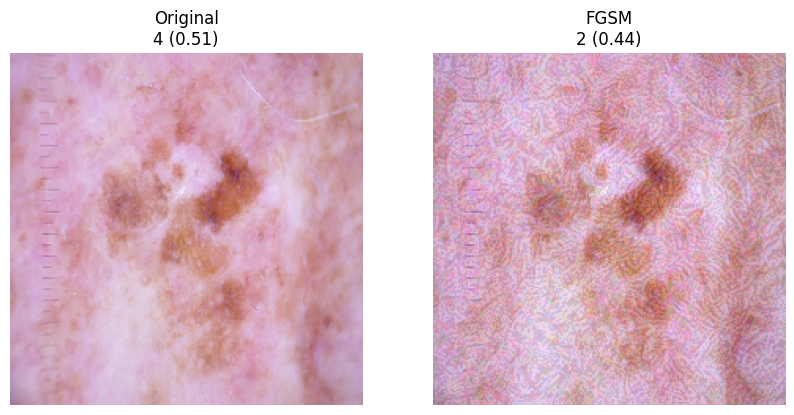

In [ ]:
import matplotlib.pyplot as plt
import os

sample_image_path = "data/HAM10000_images_part_1/ISIC_0027419.jpg"

if not os.path.exists(sample_image_path):
    print("❌ Image not found. Update path.")
else:
    print(f"Using image: {sample_image_path}")

    img_tensor = preprocess_single_image(sample_image_path)

    # Original prediction
    orig_pred = model.predict(img_tensor, verbose=0)[0]
    orig_class = np.argmax(orig_pred)
    orig_conf = orig_pred[orig_class]

    # Label for attack
    label_tensor = tf.one_hot(orig_class, len(orig_pred))
    label_tensor = tf.reshape(label_tensor, (1, len(orig_pred)))

    # FGSM attack
    epsilon = 0.05
    adv_image = fgsm_attack(model, img_tensor, label_tensor, epsilon)

    # Prediction after attack
    adv_pred = model.predict(adv_image, verbose=0)[0]
    adv_class = np.argmax(adv_pred)
    adv_conf = adv_pred[adv_class]

    print("\n--- FGSM Results ---")
    print(f"Original: Class {orig_class} | Conf {orig_conf:.4f}")
    print(f"FGSM:     Class {adv_class} | Conf {adv_conf:.4f}")

    # Plot
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title(f"Original\n{orig_class} ({orig_conf:.2f})")
    plt.imshow(img_tensor[0])
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"FGSM\n{adv_class} ({adv_conf:.2f})")
    plt.imshow(adv_image[0])
    plt.axis('off')

    plt.show()

## Adversarial Attack - PGD

PGD Attack Function

In [ ]:
def pgd_attack(model, image, label, epsilon=0.05, alpha=0.01, iterations=10):
    # ✅ Convert to tensor
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    adv_image = tf.identity(image)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_image)
            prediction = model(adv_image, training=False)
            loss = tf.keras.losses.categorical_crossentropy(label, prediction)

        gradient = tape.gradient(loss, adv_image)

        adv_image = adv_image + alpha * tf.sign(gradient)

        # Project within epsilon ball
        adv_image = tf.clip_by_value(adv_image, image - epsilon, image + epsilon)

        # Keep valid image range
        adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image

Run PGD Attack


--- PGD Results ---
Original: Class 4 | Conf 0.5116
PGD:      Class 2 | Conf 1.0000


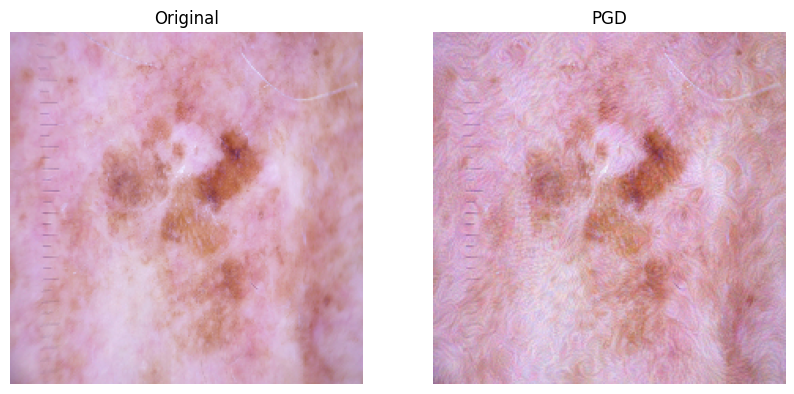

In [ ]:
# PGD attack
pgd_image = pgd_attack(model, img_tensor, label_tensor)

pgd_pred = model.predict(pgd_image, verbose=0)[0]
pgd_class = np.argmax(pgd_pred)
pgd_conf = pgd_pred[pgd_class]

print("\n--- PGD Results ---")
print(f"Original: Class {orig_class} | Conf {orig_conf:.4f}")
print(f"PGD:      Class {pgd_class} | Conf {pgd_conf:.4f}")

# Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_tensor[0])
plt.axis('off')

plt.subplot(1,2,2)
plt.title("PGD")
plt.imshow(pgd_image[0])
plt.axis('off')

plt.show()

# Carlini & Wagner (CW) Attack Function

In [ ]:
import tensorflow as tf

def cw_attack(model, image, label, c=1e-3, lr=0.01, iterations=50):
    """
    Simplified CW Attack (L2-based)
    """

    # Convert to variable
    adv_image = tf.Variable(image)

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            prediction = model(adv_image, training=False)

            # Classification loss
            real = tf.reduce_sum(label * prediction, axis=1)
            other = tf.reduce_max((1 - label) * prediction - label * 1e4, axis=1)

            # CW loss
            loss1 = tf.maximum(other - real, 0)
            loss2 = tf.reduce_sum(tf.square(adv_image - image), axis=[1,2,3])

            loss = c * loss1 + loss2

        grads = tape.gradient(loss, adv_image)
        optimizer.apply_gradients([(grads, adv_image)])

        # Keep image valid
        adv_image.assign(tf.clip_by_value(adv_image, 0, 1))

    return adv_image

## Defense - Feature Squeezing

Defense Functions

In [ ]:
def bit_depth_reduction(img, bits=4):
    levels = 2 ** bits
    img = tf.floor(img * levels) / levels
    return img

def gaussian_blur(img):
    return tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')

Apply Defense on FGSM Image

In [ ]:
defended_fgsm = gaussian_blur(bit_depth_reduction(adv_image))

def_pred = model.predict(defended_fgsm, verbose=0)[0]
def_class = np.argmax(def_pred)
def_conf = def_pred[def_class]

print("\n--- FGSM Defense ---")
print(f"Before: Class {adv_class} | Conf {adv_conf:.4f}")
print(f"After:  Class {def_class} | Conf {def_conf:.4f}")


--- FGSM Defense ---
Before: Class 2 | Conf 0.4372
After:  Class 2 | Conf 0.3580


PGD Defense

In [ ]:
defended_pgd = gaussian_blur(bit_depth_reduction(pgd_image))

pgd_def_pred = model.predict(defended_pgd, verbose=0)[0]
pgd_def_class = np.argmax(pgd_def_pred)
pgd_def_conf = pgd_def_pred[pgd_def_class]

print("\n--- PGD Defense ---")
print(f"Before: Class {pgd_class} | Conf {pgd_conf:.4f}")
print(f"After:  Class {pgd_def_class} | Conf {pgd_def_conf:.4f}")


--- PGD Defense ---
Before: Class 2 | Conf 1.0000
After:  Class 2 | Conf 0.6334


Run CW Attack + Defense (MobileNet example)

CW Visualization

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(img_tensor[0])
plt.axis('off')
plt.subplot(1,4,2)
plt.title("CW")
plt.imshow(cw_img[0])
plt.axis('off')

plt.subplot(1,4,3)
plt.title("CW + Defense")
plt.imshow(defended_cw[0])
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Noise")
plt.imshow((cw_img - img_tensor)[0])
plt.axis('off')

plt.show()

Final Visualization

In [ ]:
plt.figure(figsize=(18,6))

# 1. Original
plt.subplot(1,5,1)
plt.title("Original")
plt.imshow(img_tensor[0])
plt.axis('off')

# 2. FGSM
plt.subplot(1,5,2)
plt.title("FGSM")
plt.imshow(adv_image[0])
plt.axis('off')

# 3. FGSM + Defense
plt.subplot(1,5,3)
plt.title("FGSM + Defense")
plt.imshow(defended_fgsm[0])
plt.axis('off')

# 4. PGD
plt.subplot(1,5,4)
plt.title("PGD")
plt.imshow(pgd_image[0])
plt.axis('off')

# 5. PGD + Defense
plt.subplot(1,5,5)
plt.title("PGD + Defense")
plt.imshow(defended_pgd[0])
plt.axis('off')

plt.tight_layout()
plt.show()

# **EFFICIENTNET-B0**

Rebuild EfficientNet Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Rebuild base model
base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Recreate head (⚠️ MUST match training)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(7, activation='softmax')(x)

model_eff = models.Model(inputs=base_model.input, outputs=output)

print("✅ EfficientNet architecture rebuilt")

Load EfficientNet Weights

In [ ]:
model_eff.load_weights("efficientnet_best_model.h5")

model_eff.trainable = False

print("✅ EfficientNet weights loaded")

Reuse FGSM / PGD / Defense Functions

In [ ]:
import numpy as np
import tensorflow as tf

def fgsm_attack(model, image, label, epsilon):
    image = tf.cast(image, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image, training=False)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)

    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)

    adv_image = image + epsilon * signed_grad
    adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image


def pgd_attack(model, image, label, epsilon=0.05, alpha=0.01, iterations=10):
    adv_image = image

    for i in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_image)
            prediction = model(adv_image, training=False)
            loss = tf.keras.losses.categorical_crossentropy(label, prediction)

        gradient = tape.gradient(loss, adv_image)
        adv_image = adv_image + alpha * tf.sign(gradient)

        adv_image = tf.clip_by_value(adv_image, image - epsilon, image + epsilon)
        adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image


def feature_squeeze(img, bit_depth=4):
    levels = 2 ** bit_depth
    return np.round(img * (levels - 1)) / (levels - 1)


def gaussian_blur(img):
    return tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')

In [ ]:
import numpy as np

# Load image
sample_image_path = "data/HAM10000_images_part_1/ISIC_0027419.jpg"

img_tensor = preprocess_single_image(sample_image_path)
img_tensor = tf.convert_to_tensor(img_tensor, dtype=tf.float32)

# Original prediction
orig_pred = model.predict(img_tensor, verbose=0)[0]
orig_class = np.argmax(orig_pred)
orig_conf = orig_pred[orig_class]

# Label
label_tensor = tf.one_hot(orig_class, len(orig_pred))
label_tensor = tf.reshape(label_tensor, (1, len(orig_pred)))

# ================= CW Attack =================
cw_img = cw_attack(model, img_tensor, label_tensor)

cw_pred = model.predict(cw_img, verbose=0)[0]
cw_class = np.argmax(cw_pred)
cw_conf = cw_pred[cw_class]

# ================= Defense =================
defended_cw = feature_squeeze(cw_img)

def_pred = model.predict(defended_cw, verbose=0)[0]
def_class = np.argmax(def_pred)
def_conf = def_pred[def_class]

# ================= Results =================
print("\n--- CW Attack Results ---")
print(f"Original: Class {orig_class} | Conf {orig_conf:.4f}")
print(f"CW Attack: Class {cw_class} | Conf {cw_conf:.4f}")
print(f"After Defense: Class {def_class} | Conf {def_conf:.4f}")


--- CW Attack Results ---
Original: Class 4 | Conf 0.5116
CW Attack: Class 4 | Conf 0.5116
After Defense: Class 2 | Conf 0.5147


Run EfficientNet Attack + Defense + Visualization

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
import tensorflow as tf

# ---------- PREPROCESS FUNCTION ----------
def preprocess_single_image(path):
    from tensorflow.keras.preprocessing import image
    img = image.load_img(path, target_size=(224, 224))
    img = image.img_to_array(img) / 255.0
    return np.expand_dims(img, axis=0)

# ---------- FGSM ----------
def fgsm_attack(model, image, label, epsilon):
    image = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image, training=False)
        loss = tf.keras.losses.categorical_crossentropy(label, prediction)

    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)

    adv_image = image + epsilon * signed_grad
    adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image

# ---------- PGD ----------
def pgd_attack(model, image, label, epsilon=0.05, alpha=0.01, iterations=10):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    adv_image = tf.identity(image)

    for i in range(iterations):
        with tf.GradientTape() as tape:
            tape.watch(adv_image)
            prediction = model(adv_image, training=False)
            loss = tf.keras.losses.categorical_crossentropy(label, prediction)

        gradient = tape.gradient(loss, adv_image)

        adv_image = adv_image + alpha * tf.sign(gradient)

        adv_image = tf.clip_by_value(adv_image, image - epsilon, image + epsilon)
        adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image

# ---------- DEFENSE ----------
def feature_squeeze(img, bit_depth=4):
    levels = 2 ** bit_depth
    return np.round(img * (levels - 1)) / (levels - 1)

def gaussian_blur(img):
    return tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')

# ---------- IMAGE PATH ----------
sample_image_path = "data/HAM10000_images_part_1/ISIC_0027419.jpg"

# ---------- MAIN PIPELINE ----------
if not os.path.exists(sample_image_path):
    print("❌ Image not found")
else:
    print("Using:", sample_image_path)

    # PREPROCESS
    img_tensor = preprocess_single_image(sample_image_path)
    img_tensor = tf.convert_to_tensor(img_tensor, dtype=tf.float32)

    # ORIGINAL
    orig_pred = model_eff.predict(img_tensor, verbose=0)[0]
    orig_class = np.argmax(orig_pred)
    orig_conf = orig_pred[orig_class]

    label_tensor = tf.one_hot(orig_class, len(orig_pred))
    label_tensor = tf.reshape(label_tensor, (1, len(orig_pred)))

    # FGSM
    fgsm_img = fgsm_attack(model_eff, img_tensor, label_tensor, epsilon=0.05)
    fgsm_pred = model_eff.predict(fgsm_img, verbose=0)[0]
    fgsm_class = np.argmax(fgsm_pred)
    fgsm_conf = fgsm_pred[fgsm_class]

    # PGD
    pgd_img = pgd_attack(model_eff, img_tensor, label_tensor)
    pgd_pred = model_eff.predict(pgd_img, verbose=0)[0]
    pgd_class = np.argmax(pgd_pred)
    pgd_conf = pgd_pred[pgd_class]

    # DEFENSE FGSM
    def_fgsm = feature_squeeze(fgsm_img.numpy())
    def_fgsm = gaussian_blur(def_fgsm)

    def_fgsm_pred = model_eff.predict(def_fgsm, verbose=0)[0]
    def_fgsm_class = np.argmax(def_fgsm_pred)
    def_fgsm_conf = def_fgsm_pred[def_fgsm_class]

    # DEFENSE PGD
    def_pgd = feature_squeeze(pgd_img.numpy())
    def_pgd = gaussian_blur(def_pgd)

    def_pgd_pred = model_eff.predict(def_pgd, verbose=0)[0]
    def_pgd_class = np.argmax(def_pgd_pred)
    def_pgd_conf = def_pgd_pred[def_pgd_class]

    # ---------- PRINT ----------
    print("\n--- EfficientNet Results ---")
    print(f"Original: Class {orig_class} | {orig_conf:.4f}")
    print(f"FGSM:     Class {fgsm_class} | {fgsm_conf:.4f}")
    print(f"FGSM+Def: Class {def_fgsm_class} | {def_fgsm_conf:.4f}")
    print(f"PGD:      Class {pgd_class} | {pgd_conf:.4f}")
    print(f"PGD+Def:  Class {def_pgd_class} | {def_pgd_conf:.4f}")

    # ---------- VISUALIZATION ----------
    plt.figure(figsize=(15,6))

    plt.subplot(1,5,1)
    plt.title("Original")
    plt.imshow(img_tensor.numpy()[0])
    plt.axis('off')

    plt.subplot(1,5,2)
    plt.title("FGSM")
    plt.imshow(fgsm_img.numpy()[0])
    plt.axis('off')

    plt.subplot(1,5,3)
    plt.title("FGSM + Def")
    plt.imshow(def_fgsm[0])
    plt.axis('off')

    plt.subplot(1,5,4)
    plt.title("PGD")
    plt.imshow(pgd_img.numpy()[0])
    plt.axis('off')

    plt.subplot(1,5,5)
    plt.title("PGD + Def")
    plt.imshow(def_pgd[0])
    plt.axis('off')

    plt.show()

Using: data/HAM10000_images_part_1/ISIC_0027419.jpg


NameError: name 'model_eff' is not defined

# **RESNET50**

Rebuild ResNet50 Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Build base model
base_model_res = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(224, 224, 3)
)

# Classification head (must match training)
x = base_model_res.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(7, activation='softmax')(x)

# Final model
model_res = models.Model(inputs=base_model_res.input, outputs=output)

print("✅ ResNet50 architecture rebuilt")

Load ResNet50 Weights

In [ ]:
import os

weights_path = "resnet_best_model.h5"   # ⚠️ Change if needed

if os.path.exists(weights_path):
    model_res.load_weights(weights_path)
    model_res.trainable = False
    print("✅ ResNet weights loaded successfully")
else:
    print(f"❌ File not found: {weights_path}")
    print("👉 Check your model file name")

Run ResNet50 Attack + Defense + Visualization

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# STEP 1: Select Image
# =========================
sample_image_path = "data/HAM10000_images_part_1/ISIC_0027419.jpg"

if not os.path.exists(sample_image_path):
    print("❌ Image not found. Update path.")
else:
    print(f"Using image: {sample_image_path}")

    # =========================
    # STEP 2: Preprocess
    # =========================
    img_tensor = preprocess_single_image(sample_image_path)
    img_tensor = tf.convert_to_tensor(img_tensor, dtype=tf.float32)

    # =========================
    # STEP 3: Original Prediction
    # =========================
    orig_pred = model_res.predict(img_tensor, verbose=0)[0]
    orig_class = np.argmax(orig_pred)
    orig_conf = orig_pred[orig_class]

    # Create label tensor
    label_tensor = tf.one_hot(orig_class, len(orig_pred))
    label_tensor = tf.reshape(label_tensor, (1, len(orig_pred)))

    # =========================
    # STEP 4: FGSM Attack
    # =========================
    epsilon = 0.05
    adv_image = fgsm_attack(model_res, img_tensor, label_tensor, epsilon)

    adv_pred = model_res.predict(adv_image, verbose=0)[0]
    adv_class = np.argmax(adv_pred)
    adv_conf = adv_pred[adv_class]

    # =========================
    # STEP 5: PGD Attack
    # =========================
    pgd_image = pgd_attack(model_res, img_tensor, label_tensor)

    pgd_pred = model_res.predict(pgd_image, verbose=0)[0]
    pgd_class = np.argmax(pgd_pred)
    pgd_conf = pgd_pred[pgd_class]

    # =========================
    # STEP 6: Defense (Feature Squeezing)
    # =========================
    defended_fgsm = feature_squeeze(adv_image)
    defended_pgd = feature_squeeze(pgd_image)

    def_pred_fgsm = model_res.predict(defended_fgsm, verbose=0)[0]
    def_class_fgsm = np.argmax(def_pred_fgsm)
    def_conf_fgsm = def_pred_fgsm[def_class_fgsm]

    def_pred_pgd = model_res.predict(defended_pgd, verbose=0)[0]
    def_class_pgd = np.argmax(def_pred_pgd)
    def_conf_pgd = def_pred_pgd[def_class_pgd]

    # =========================
    # STEP 7: Print Results
    # =========================
    print("\n========== RESNET50 RESULTS ==========")
    print(f"Original      → Class {orig_class} | Conf {orig_conf:.4f}")
    print(f"FGSM Attack   → Class {adv_class} | Conf {adv_conf:.4f}")
    print(f"PGD Attack    → Class {pgd_class} | Conf {pgd_conf:.4f}")
    print(f"FGSM Defense  → Class {def_class_fgsm} | Conf {def_conf_fgsm:.4f}")
    print(f"PGD Defense   → Class {def_class_pgd} | Conf {def_conf_pgd:.4f}")

    # =========================
    # STEP 8: Visualization
    # =========================
    plt.figure(figsize=(15,5))

    plt.subplot(1,4,1)
    plt.title("Original")
    plt.imshow(img_tensor[0])
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.title("FGSM")
    plt.imshow(adv_image[0])
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.title("PGD")
    plt.imshow(pgd_image[0])
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.title("Defense")
    plt.imshow(defended_fgsm[0])
    plt.axis('off')

    plt.show()

# **Final Model Robustness Comparison (MobileNet vs EfficientNet vs ResNet)**

In [ ]:
def evaluate_model(model, model_name):

    # Original prediction
    orig_pred = model.predict(img_tensor, verbose=0)[0]
    orig_class = np.argmax(orig_pred)
    orig_conf = float(orig_pred[orig_class])

    # Label for attacks
    label_tensor = tf.one_hot(orig_class, len(orig_pred))
    label_tensor = tf.reshape(label_tensor, (1, len(orig_pred)))

    # ================= FGSM =================
    fgsm_img = fgsm_attack(model, img_tensor, label_tensor, epsilon=0.05)
    fgsm_pred = model.predict(fgsm_img, verbose=0)[0]
    fgsm_class = np.argmax(fgsm_pred)
    fgsm_conf = float(fgsm_pred[fgsm_class])

    # ================= PGD =================
    pgd_img = pgd_attack(model, img_tensor, label_tensor)
    pgd_pred = model.predict(pgd_img, verbose=0)[0]
    pgd_class = np.argmax(pgd_pred)
    pgd_conf = float(pgd_pred[pgd_class])

    # ================= CW =================
    cw_img = cw_attack(model, img_tensor, label_tensor)
    cw_pred = model.predict(cw_img, verbose=0)[0]
    cw_class = np.argmax(cw_pred)
    cw_conf = float(cw_pred[cw_class])

    # ================= DEFENSE =================
    def_fgsm = feature_squeeze(fgsm_img)
    def_pgd = feature_squeeze(pgd_img)
    def_cw = feature_squeeze(cw_img)

    def_pred_fgsm = model.predict(def_fgsm, verbose=0)[0]
    def_pred_pgd = model.predict(def_pgd, verbose=0)[0]
    def_pred_cw = model.predict(def_cw, verbose=0)[0]

    def_class_fgsm = np.argmax(def_pred_fgsm)
    def_class_pgd = np.argmax(def_pred_pgd)
    def_class_cw = np.argmax(def_pred_cw)

    def_conf_fgsm = float(def_pred_fgsm[def_class_fgsm])
    def_conf_pgd = float(def_pred_pgd[def_class_pgd])
    def_conf_cw = float(def_pred_cw[def_class_cw])

    return {
        "Model": model_name,

        "Original_Class": orig_class,
        "Original_Conf": round(orig_conf, 4),

        "FGSM_Class": fgsm_class,
        "FGSM_Conf": round(fgsm_conf, 4),

        "PGD_Class": pgd_class,
        "PGD_Conf": round(pgd_conf, 4),

        "CW_Class": cw_class,
        "CW_Conf": round(cw_conf, 4),

        "Def_FGSM_Class": def_class_fgsm,
        "Def_FGSM_Conf": round(def_conf_fgsm, 4),

        "Def_PGD_Class": def_class_pgd,
        "Def_PGD_Conf": round(def_conf_pgd, 4),

        "Def_CW_Class": def_class_cw,
        "Def_CW_Conf": round(def_conf_cw, 4),

        "FGSM_Changed": orig_class != fgsm_class,
        "PGD_Changed": orig_class != pgd_class,
        "CW_Changed": orig_class != cw_class,

        "Recovered_FGSM": def_class_fgsm == orig_class,
        "Recovered_PGD": def_class_pgd == orig_class,
        "Recovered_CW": def_class_cw == orig_class
    }